In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pathlib
import shutil
import os
import requests
import time

curr_dir = pathlib.Path(".")
data_dir = curr_dir / "RTS-GMLC-master" / "RTS_Data"
load_data_dir = curr_dir / "load-data"

In [21]:
# Read in API key
with open("eia-api-key.txt", "r") as f:
    API_KEY = f.readlines()[0].strip()

In [27]:
BASE_URL = "https://api.eia.gov/v2/electricity/rto/region-data/data/"

RESPONDENTS = ["AZPS", "PNM", "SRP"]

START_DATE = "2016-01-01T00"
END_DATE   = "2018-12-31T00"

MAX_ROWS = 5000  # API row limit per request
DELAY = 0.2      # seconds between requests to avoid rate limits

def fetch_page(offset=0):
    """Fetch a single page of results from the EIA API."""
    params = {
        "api_key": API_KEY,
        "frequency": "hourly",
        "data[0]": "value",
        "facets[respondent][]": RESPONDENTS,
        "start": START_DATE,
        "end": END_DATE,
        "sort[0][column]": "period",
        "sort[0][direction]": "desc",
        "offset": offset,
        "length": MAX_ROWS
    }
    response = requests.get(BASE_URL, params=params)
    response.raise_for_status()
    data = response.json().get("response", {}).get("data", [])
    return data

def fetch_all_data():
    """Fetch all rows by paginating through the API."""
    all_data = []
    offset = 0
    
    while True:
        print(f"Fetching rows starting at offset {offset} ...")
        page = fetch_page(offset)
        if not page:
            break
        all_data.extend(page)
        if len(page) < MAX_ROWS:
            break
        offset += MAX_ROWS
        time.sleep(DELAY)
    
    print(f"Total rows fetched: {len(all_data)}")
    return all_data

def main():
    data = fetch_all_data()
    if not data:
        print("No data retrieved.")
        return
    
    df = pd.DataFrame(data)
    df['datetime'] = pd.to_datetime(df['period'])
    df = df.sort_values(['respondent', 'datetime'])
    
    # Save to CSV
    df.to_csv("EIA_hourly_load_2016_2018.csv", index=False)
    print("Saved to EIA_hourly_load_2016_2018.csv")

if __name__ == "__main__":
    main()

Fetching rows starting at offset 0 ...
Total rows fetched: 0
No data retrieved.


In [111]:
# Read-in and organize load data
df = pd.read_csv(load_data_dir / "EIA_hourly_load_2019_2025.csv")
df_load = df.loc[df["type-name"] == "Demand"]
df_load = df_load.pivot(index=["datetime"], columns=["respondent"], values=["value"])
df_load.columns = df_load.columns.droplevel(0)
df_load.index = pd.to_datetime(df_load.index)

<Axes: xlabel='datetime'>

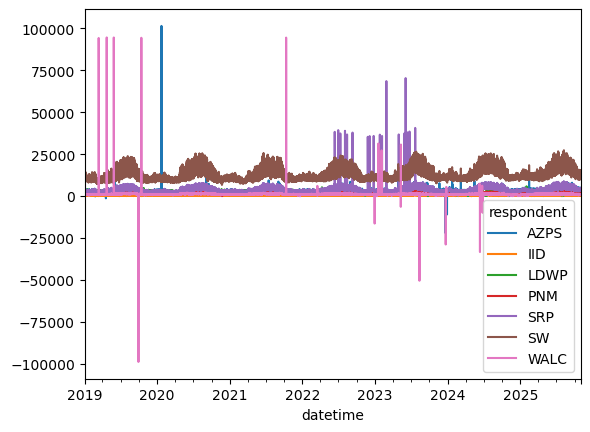

In [112]:
# Clean load data
df_load.plot()

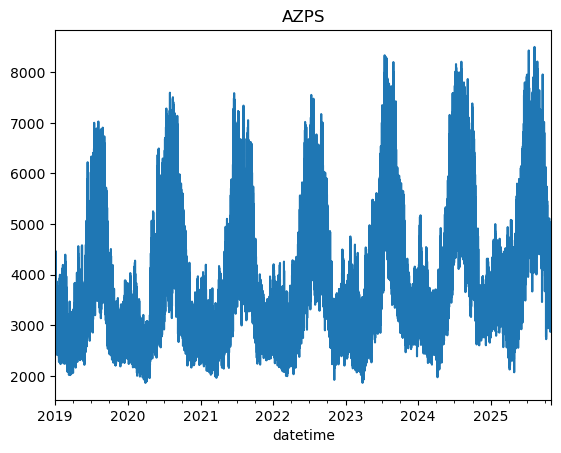

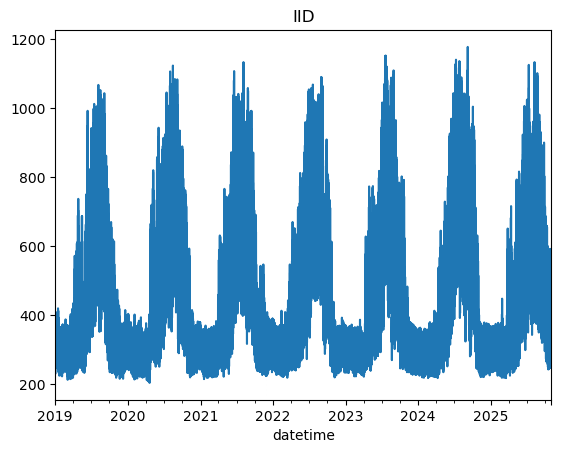

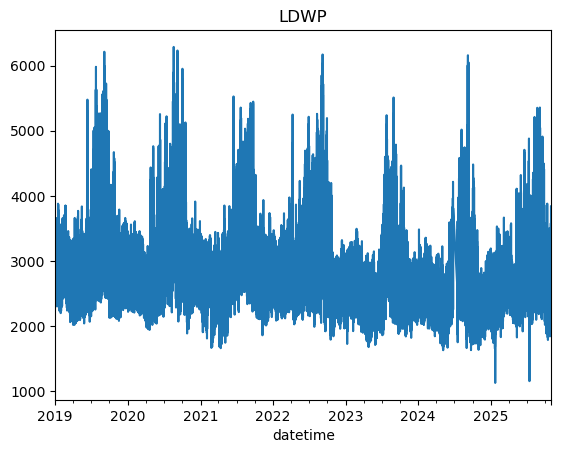

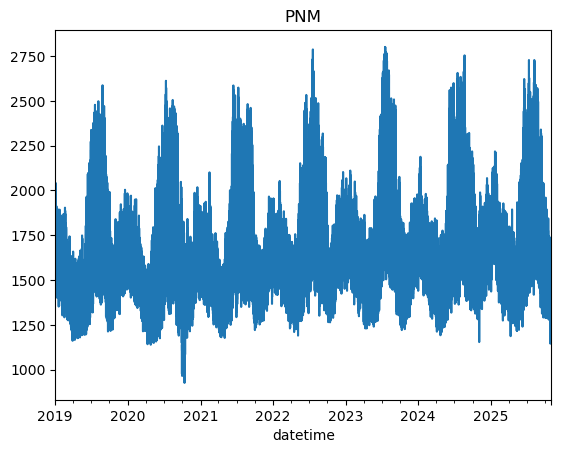

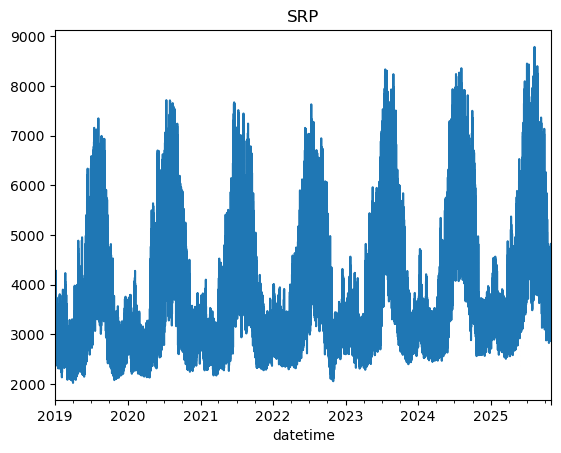

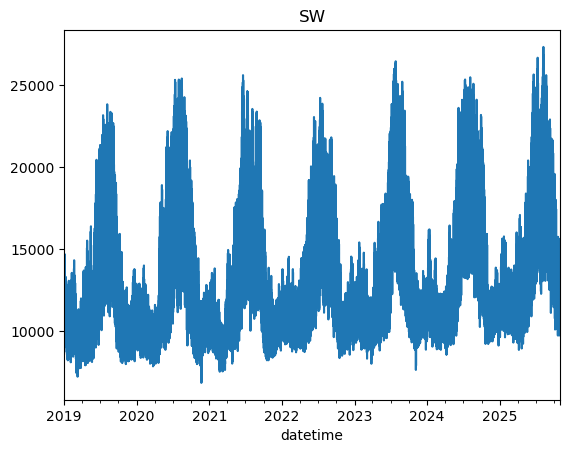

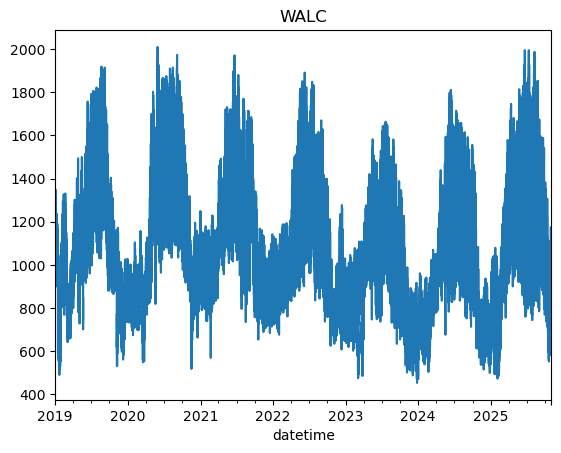

In [180]:
df_load_clean = df_load.copy()
low_cutoffs = {col: 100 for col in df_load_clean.columns}
low_cutoffs["LDWP"] = 1000
low_cutoffs["WALC"] = 400
for col in df_load.columns:
    
    # Identify large percentage changes in data (indicating erroneous data)
    bwd_pct_change = (df_load_clean[col] + 1).pct_change(periods=1, fill_method=None).abs()
    fwd_pct_change = (df_load_clean[col] + 1).pct_change(periods=-1, fill_method=None).abs()
    pct_change = pd.concat([fwd_pct_change, bwd_pct_change], axis=1).max(axis=1)
    big_deltas = (pct_change > 0.2)
    
    # Identify where time series is below cutoff
    zeros = (df_load_clean[col] < low_cutoffs[col])

    # Flag index at these times
    flag_inds = df_load_clean[col].index[big_deltas | zeros]
    
    # Remove data at these times
    df_load_clean.loc[flag_inds, col] = np.nan
    
    # Identify large rolling z-scores
    window = 168
    rolling_mean = df_load_clean[col].rolling(window=window, min_periods=1, center=True).mean()
    rolling_std = df_load_clean[col].rolling(window=window, min_periods=1, center=True).std()
    rolling_zscore = (df_load_clean[col] - rolling_mean) / rolling_std
    big_zscores = (rolling_zscore > 3)

    # Flag index at these times
    flag_inds = df_load_clean[col].index[big_deltas | zeros | big_zscores]

     # Remove data at these times
    df_load_clean.loc[flag_inds, col] = np.nan

    # Interpolate data
    df_load_clean[col] = df_load_clean[col].interpolate(method="time")
    
    # Plot cleaned data
    df_load_clean[col].plot()
    plt.title(col)
    plt.show()

AttributeError: 'DatetimeIndex' object has no attribute 'timezone'

<Axes: xlabel='datetime'>

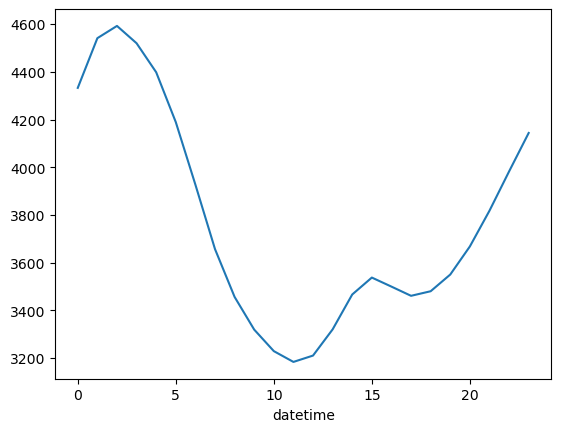

In [195]:
df_load_clean.groupby(df_load_clean.index.hour).mean()["AZPS"].plot()